# Import Library

In [1]:
import pandas as pd

# Data Loading

In [2]:
kronos_df = pd.read_csv("./data/eur_idr_kronos_clean.csv")
kronos_df.head()

,timestamp,open,high,low,close,volume,amount
0,2021-01-01,17246.3,17246.3,17246.3,17246.3,0.0,0.0
1,2021-01-04,17184.6,17219.7,16980.1,17006.3,0.0,0.0
2,2021-01-05,17017.2,17125.2,17015.1,17091.4,0.0,0.0
3,2021-01-06,17109.9,17184.2,17042.9,17107.1,0.0,0.0
4,2021-01-07,17127.7,17190.0,17032.1,17043.0,0.0,0.0


In [3]:
print(len(kronos_df))
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())

1326
2021-01-01
2026-01-30


Convert timestamp ke datetime

In [7]:
kronos_df["timestamp"] = pd.to_datetime(
    kronos_df["timestamp"]
)

In [8]:
kronos_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  1326 non-null   datetime64[ns]
 1   open       1326 non-null   float64       
 2   high       1326 non-null   float64       
 3   low        1326 non-null   float64       
 4   close      1326 non-null   float64       
 5   volume     1326 non-null   float64       
 6   amount     1326 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 72.6 KB


In [9]:
print(len(kronos_df))
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())

1326
2021-01-01 00:00:00
2026-01-30 00:00:00


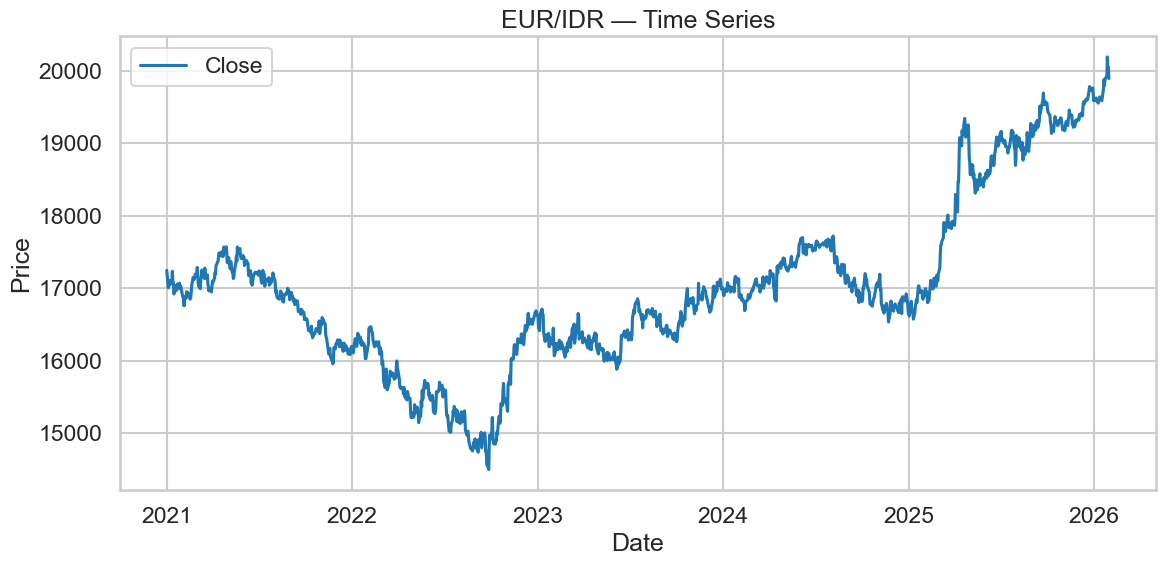

In [15]:
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sns.set(style="whitegrid", context="talk")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(kronos_df["timestamp"], kronos_df["close"], label="Close", color="tab:blue")
# ax.plot(kronos_df["timestamp"], kronos_df["open"], label="Open", color="tab:orange", alpha=0.6)
# ax.fill_between(kronos_df["timestamp"], kronos_df["low"], kronos_df["high"], color="gray", alpha=0.2, label="High-Low range")
# ax.plot(kronos_df["timestamp"], kronos_df["close"].rolling(window=20).mean(), label="MA20", linestyle="--", color="tab:green")

ax.set_title("EUR/IDR — Time Series")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.AutoDateLocator()))
plt.tight_layout()
plt.show()

## Cutting data (opsional)

In [25]:
# Ambil 18 bulan terakhir
cutoff = kronos_df["timestamp"].max() - pd.DateOffset(years=3)

df_3y = kronos_df[kronos_df["timestamp"] >= cutoff].copy()

print("Data asli :", len(kronos_df))
print("Data 18 bulan :", len(df_3y))

df_3y.head()

Data asli : 1326
Data 18 bulan : 785


,timestamp,open,high,low,close,volume,amount
541,2023-01-30,16295.4,16339.0,16225.2,16228.0,0.0,0.0
542,2023-01-31,16242.5,16302.4,16191.5,16276.7,0.0,0.0
543,2023-02-01,16285.1,16474.7,16249.9,16450.5,0.0,0.0
544,2023-02-02,16457.5,16524.2,16196.9,16228.6,0.0,0.0
545,2023-02-03,16232.6,16293.1,16071.2,16070.8,0.0,0.0


In [26]:
print(len(df_3y))
print(df_3y["timestamp"].min())
print(df_3y["timestamp"].max())

785
2023-01-30 00:00:00
2026-01-30 00:00:00


In [27]:
df_3y.to_csv(
    "./data/eur_idr_kronos_3y.csv",
    index=False
)

# Load model

In [8]:
import sys
sys.path.append("./Kronos")  # sesuaikan dengan lokasi folder Kronos

In [9]:
from model import Kronos, KronosTokenizer, KronosPredictor

In [10]:
# tokenizer = KronosTokenizer.from_pretrained("NeoQuasar/Kronos-Tokenizer-base")
# model = Kronos.from_pretrained("NeoQuasar/Kronos-base")

tokenizer = KronosTokenizer.from_pretrained("./Kronos/finetuned/eur_idr_daily/tokenizer/best_model")
model = Kronos.from_pretrained("./Kronos/finetuned/eur_idr_daily/basemodel/best_model")

Loading weights from local directory
Loading weights from local directory


In [11]:
predictor = KronosPredictor(model, tokenizer, max_context=512)

# inference

In [13]:
x_df = kronos_df[["open", "high", "low", "close"]]
x_timestamp = kronos_df["timestamp"]

In [14]:
print(kronos_df["timestamp"].min())
print(kronos_df["timestamp"].max())


2021-01-01 00:00:00
2026-01-30 00:00:00


In [15]:
import pandas as pd

prediction_length = 30

last_date = kronos_df["timestamp"].max()
future_dates = pd.Series(
    pd.date_range(
        start=last_date + pd.offsets.BDay(1),
        periods=prediction_length,
        freq="B"
    )
)

In [16]:
forecast = predictor.predict(
    df=x_df,
    x_timestamp=x_timestamp,
    y_timestamp=future_dates,
    pred_len=prediction_length,
    T=0.7,
    top_p=0.9,
    sample_count=20,
    verbose=True
)

100%|██████████| 30/30 [13:55<00:00, 27.84s/it]


In [17]:
forecast

,open,high,low,close,volume,amount
2026-02-02,16974.660156,17261.066406,15761.481445,16412.244141,8.201300e-06,5.372940e-06
2026-02-03,16547.208984,16568.082031,15970.456055,16259.891602,6.102369e-06,4.623325e-06
2026-02-04,16277.671875,16372.326172,15934.314453,16244.937500,7.300042e-06,6.449923e-06
2026-02-05,16246.042969,16355.810547,15917.189453,16236.866211,2.045090e-06,1.338342e-06
2026-02-06,16291.432617,16351.794922,16150.386719,16291.340820,4.670904e-06,4.576216e-06
2026-02-09,16389.066406,16480.947266,16138.694336,16332.207031,4.195816e-06,3.857886e-06
2026-02-10,16402.972656,16503.873047,16119.776367,16370.229492,5.481912e-06,4.975853e-06
2026-02-11,16302.441406,16464.509766,16097.800781,16368.120117,4.058276e-06,3.222603e-06
2026-02-12,16369.240234,16430.451172,16196.588867,16326.687500,5.872855e-07,4.002093e-07
2026-02-13,16351.676758,16411.595703,16167.987305,16327.407227,9.618816e-07,7.646579e-07
